# 교통 시설 시군구 집계

## 분석 목적과 범위

고속도로 출입시설(IC/JC), 버스정류장, 철도역, 고속버스터미널을
`전국_시군구_2025_2Q.geojson` 시군구 경계에 공간 결합해, 국민여행조사
전용 지역코드의 시도+시군구 229개를 기준으로 시군구별 개수를 wide
형태로 산출한다.

- 고속도로 출입시설: IC 개수, JC 개수, 총합
- 버스정류장: 개수
- 철도역: 개수
- 고속버스터미널: 개수

버스정류장·철도역은 원본이 위도·경도만 있는 CSV라 이 노트북에서
GeoDataFrame으로 변환하고, `data/preprocess/transportation/`에
geojson으로도 저장한다. 고속버스터미널은 원본이 이미 geojson(좌표계
EPSG:5179)이라 좌표계만 다른 원자료와 맞춘 뒤 그대로 쓴다. 이 표는
이후 국민여행조사 전용 지역코드 CSV와 결합하는 것을 목표로 한다.
여기서는 결합·전처리와 결과 검증까지만 다룬다.

## 행정구역 표기 보정

- 국민여행조사 전용 지역코드는 군위군을 경상북도로 표기한다(2023년
  대구광역시 편입 이전 명칭). 이 노트북은 원본 CSV는 그대로 두고 key
  테이블 안에서만 군위군의 시도명을 대구광역시로 고친다.
- 시군구 경계 geojson은 인천 남구를 2018년 개칭된 미추홀구로 쓴다.
  지역코드가 쓰는 옛 이름(남구)에 맞춰 결합 전에 고친다.
- 위 보정은 모두 이 노트북 코드 안에서만 적용하고 원본 파일은 고치지
  않는다.

## 환경, 공통 경로, 재현성 설정

In [1]:
from pathlib import Path
import sys
import warnings

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("src 폴더가 있는 프로젝트 루트를 찾지 못했습니다.")
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Point

from src.path import (
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR,
    PREPROCESS_DATA_DIR,
    RAW_DATA_DIR,
    create_output_directories,
)
from src.visualization import COLORS, apply_plot_style

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 20)
apply_plot_style()
FIGURES_DIR, TABLES_DIR = create_output_directories(
    "260723_교통_시설_시군구_집계.ipynb"
)

REGION_CODE_PATH = (
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR / "national_travel_survey_region_code.csv"
)
SIGUNGU_GEOJSON_PATH = RAW_DATA_DIR / "sigungu_map" / "전국_시군구_2025_2Q.geojson"
ROAD_ENTRANCE_GEOJSON_PATH = RAW_DATA_DIR / "road_entrance" / "고속도로_출입시설.geojson"
BUS_STOP_CSV_PATH = (
    RAW_DATA_DIR / "transportation" / "국토교통부_전국 버스정류장 위치정보_20251031.csv"
)
RAIL_STATION_CSV_PATH = (
    RAW_DATA_DIR / "transportation" / "한국철도공사_역 위치 정보_20240401.csv"
)
BUS_TERMINAL_GEOJSON_PATH = RAW_DATA_DIR / "transportation" / "고속터미널_5179.geojson"
TRANSPORTATION_PREPROCESS_DIR = PREPROCESS_DATA_DIR / "transportation"
TRANSPORTATION_PREPROCESS_DIR.mkdir(parents=True, exist_ok=True)
BUS_STOP_GEOJSON_PATH = (
    TRANSPORTATION_PREPROCESS_DIR / "국토교통부_전국버스정류장위치정보_20251031.geojson"
)
RAIL_STATION_GEOJSON_PATH = (
    TRANSPORTATION_PREPROCESS_DIR / "한국철도공사_역위치정보_20240401.geojson"
)

# 시군구 경계 SIGUNGU_CD 앞 2자리 -> 지역코드가 쓰는 시도명
PROVINCE_BY_CODE_PREFIX = {
    "11": "서울특별시", "21": "부산광역시", "22": "대구광역시", "23": "인천광역시",
    "24": "광주광역시", "25": "대전광역시", "26": "울산광역시", "29": "세종특별자치시",
    "31": "경기도", "32": "강원도", "33": "충청북도", "34": "충청남도",
    "35": "전라북도", "36": "전라남도", "37": "경상북도", "38": "경상남도",
    "39": "제주특별자치도",
}

print(f"지역코드: {REGION_CODE_PATH.relative_to(PROJECT_ROOT)}")
print(f"시군구 경계: {SIGUNGU_GEOJSON_PATH.relative_to(PROJECT_ROOT)}")
print(f"고속도로 출입시설: {ROAD_ENTRANCE_GEOJSON_PATH.relative_to(PROJECT_ROOT)}")
print(f"버스정류장: {BUS_STOP_CSV_PATH.relative_to(PROJECT_ROOT)}")
print(f"철도역: {RAIL_STATION_CSV_PATH.relative_to(PROJECT_ROOT)}")
print(f"고속버스터미널: {BUS_TERMINAL_GEOJSON_PATH.relative_to(PROJECT_ROOT)}")

지역코드: data\raw\national_travel_survey\national_travel_survey_region_code.csv
시군구 경계: data\raw\sigungu_map\전국_시군구_2025_2Q.geojson
고속도로 출입시설: data\raw\road_entrance\고속도로_출입시설.geojson
버스정류장: data\raw\transportation\국토교통부_전국 버스정류장 위치정보_20251031.csv
철도역: data\raw\transportation\한국철도공사_역 위치 정보_20240401.csv
고속버스터미널: data\raw\transportation\고속터미널_5179.geojson


## 1. 데이터 로드

버스정류장·철도역 CSV는 `cp949`로 인코딩돼 있다.

In [2]:
region_code = pd.read_csv(REGION_CODE_PATH)
sigungu_gdf = gpd.read_file(SIGUNGU_GEOJSON_PATH)
road_entrance_gdf = gpd.read_file(ROAD_ENTRANCE_GEOJSON_PATH)
bus_stop_df = pd.read_csv(BUS_STOP_CSV_PATH, encoding="cp949")
rail_station_df = pd.read_csv(RAIL_STATION_CSV_PATH, encoding="cp949")
bus_terminal_gdf = gpd.read_file(BUS_TERMINAL_GEOJSON_PATH)

print(f"지역코드 행 수: {len(region_code)}")
print(f"시군구 경계 원본 행 수(구 단위 포함): {len(sigungu_gdf)}")
print(f"고속도로 출입시설 point 수: {len(road_entrance_gdf)}")
print(f"버스정류장 행 수: {len(bus_stop_df)}")
print(f"철도역 행 수: {len(rail_station_df)}")
print(f"고속버스터미널 point 수: {len(bus_terminal_gdf)} (좌표계: {bus_terminal_gdf.crs})")

지역코드 행 수: 229
시군구 경계 원본 행 수(구 단위 포함): 252
고속도로 출입시설 point 수: 689
버스정류장 행 수: 227065
철도역 행 수: 202
고속버스터미널 point 수: 109 (좌표계: EPSG:5179)


## 2. 데이터 품질과 분석 단위 확인

분석 단위는 시군구(국민여행조사 전용 지역코드 229행)다. 결합 전에
각 교통시설의 유형·좌표 이상치, 군위군·인천 남구/미추홀구 표기
차이를 확인한다.

In [3]:
assert region_code[["시도_코드", "시군구_코드"]].drop_duplicates().shape[0] == len(
    region_code
), "지역코드에 (시도_코드, 시군구_코드) 중복이 있습니다."

print("고속도로 출입시설 유형(구분)별 개수:")
print(road_entrance_gdf["구분"].value_counts())

missing_geometry = road_entrance_gdf.geometry.isna()
print(f"고속도로 출입시설 geometry 결측 수: {missing_geometry.sum()}")

has_geometry = road_entrance_gdf.loc[~missing_geometry]
coord_diff_x = (has_geometry.geometry.x - has_geometry["X좌표값"]).abs()
coord_diff_y = (has_geometry.geometry.y - has_geometry["Y좌표값"]).abs()
print(
    "고속도로 출입시설 geometry-좌표값 오차 - "
    f"x 중앙값: {coord_diff_x.median():.6f}, 최대값: {coord_diff_x.max():.6f} / "
    f"y 중앙값: {coord_diff_y.median():.6f}, 최대값: {coord_diff_y.max():.6f}"
)

bus_stop_lat_lon_na = bus_stop_df["위도"].isna() | bus_stop_df["경도"].isna()
bus_stop_same_value = bus_stop_df["위도"] == bus_stop_df["경도"]
bus_stop_swapped = bus_stop_df["위도"].abs() > 90
print(
    f"버스정류장 위도·경도 결측: {bus_stop_lat_lon_na.sum()}, "
    f"위도=경도(신뢰 불가): {bus_stop_same_value.sum()}, "
    f"위도·경도 뒤바뀜(|위도|>90): {bus_stop_swapped.sum()}"
)

rail_lat_lon_na = rail_station_df["위도"].isna() | rail_station_df["경도"].isna()
rail_swapped = rail_station_df["위도"].abs() > 90
print(
    f"철도역 위도·경도 결측: {rail_lat_lon_na.sum()}, "
    f"위도·경도 뒤바뀜(|위도|>90): {rail_swapped.sum()}"
)

print(
    f"고속버스터미널 geometry 결측: {bus_terminal_gdf.geometry.isna().sum()}, "
    f"터미널명 중복: {bus_terminal_gdf['터미널'].duplicated().sum()}"
)

gunwi_row = region_code.loc[region_code["시군구명"] == "군위군"]
print(f"보정 전 지역코드 군위군 시도명: {gunwi_row['시도명'].iloc[0]}")

gunwi_geo = sigungu_gdf.loc[sigungu_gdf["SIGUNGU_NM"] == "군위군", "SIGUNGU_CD"]
print(f"시군구 경계 군위군 SIGUNGU_CD: {gunwi_geo.iloc[0]} (22XXX=대구광역시)")

print(
    "시군구 경계 인천 미추홀구 존재 여부: "
    f"{(sigungu_gdf['SIGUNGU_NM'] == '미추홀구').any()}, "
    "지역코드 인천 남구 존재 여부: "
    f"{((region_code['시도명'] == '인천광역시') & (region_code['시군구명'] == '남구')).any()}"
)

고속도로 출입시설 유형(구분)별 개수:
구분
IC    535
JC    154
Name: count, dtype: int64
고속도로 출입시설 geometry 결측 수: 33
고속도로 출입시설 geometry-좌표값 오차 - x 중앙값: 0.000000, 최대값: 0.005904 / y 중앙값: 0.000000, 최대값: 0.003690
버스정류장 위도·경도 결측: 5, 위도=경도(신뢰 불가): 1, 위도·경도 뒤바뀜(|위도|>90): 6
철도역 위도·경도 결측: 0, 위도·경도 뒤바뀜(|위도|>90): 0
고속버스터미널 geometry 결측: 0, 터미널명 중복: 0
보정 전 지역코드 군위군 시도명: 경상북도
시군구 경계 군위군 SIGUNGU_CD: 22520 (22XXX=대구광역시)
시군구 경계 인천 미추홀구 존재 여부: True, 지역코드 인천 남구 존재 여부: True


## 3. 전처리 — key 테이블(시군구 229행) 확정

지역코드의 군위군 시도명만 대구광역시로 고쳐 이 노트북에서 쓰는 key
테이블을 만든다. 원본 CSV는 고치지 않는다.

In [4]:
key_table = region_code[["시도명", "시군구명"]].copy()
key_table.loc[key_table["시군구명"] == "군위군", "시도명"] = "대구광역시"

assert key_table.duplicated().sum() == 0, "key 테이블에 중복 (시도명, 시군구명)이 있습니다."
print(f"key 테이블 행 수: {len(key_table)}")
print(
    "보정 후 군위군 시도명: "
    f"{key_table.loc[key_table['시군구명'] == '군위군', '시도명'].iloc[0]}"
)

key 테이블 행 수: 229
보정 후 군위군 시도명: 대구광역시


## 4. 전처리 — 시군구 경계 도시 단위 집계

시군구 경계에 시도명을 붙이고, 구 단위로 나뉜 도시(수원시 등)를 key
테이블과 같은 도시 단위로 `dissolve`한다. 인천 미추홀구는 key
테이블이 쓰는 옛 이름 남구로 고친다.

In [5]:
sigungu_gdf["시도명"] = sigungu_gdf["SIGUNGU_CD"].str[:2].map(PROVINCE_BY_CODE_PREFIX)
assert sigungu_gdf["시도명"].notna().all(), "매핑되지 않은 SIGUNGU_CD가 있습니다."

sigungu_gdf["시군구명"] = sigungu_gdf["SIGUNGU_NM"].str.split(" ").str[0]
is_incheon_michuhol = (sigungu_gdf["시도명"] == "인천광역시") & (
    sigungu_gdf["시군구명"] == "미추홀구"
)
sigungu_gdf.loc[is_incheon_michuhol, "시군구명"] = "남구"

city_gdf = sigungu_gdf.dissolve(by=["시도명", "시군구명"], as_index=False)[
    ["시도명", "시군구명", "geometry"]
]
city_gdf_projected = city_gdf.to_crs(epsg=5179)

unmatched_city = key_table.merge(
    city_gdf[["시도명", "시군구명"]], on=["시도명", "시군구명"], how="outer", indicator=True
)
unmatched_city = unmatched_city.loc[unmatched_city["_merge"] != "both"]
assert unmatched_city.empty, f"key 테이블과 시군구 경계 결합에 실패한 지역이 있습니다:\n{unmatched_city}"

print(f"도시 단위로 합친 시군구 경계 행 수: {len(city_gdf)}")

도시 단위로 합친 시군구 경계 행 수: 229


## 5. 전처리 — 결측 geometry 복원과 GeoDataFrame 생성

고속도로 출입시설은 geometry가 비어 있는 point를 속성의
`X좌표값`/`Y좌표값`으로 복원한다. 버스정류장·철도역은 CSV의
위도·경도로 GeoDataFrame을 만들되, 버스정류장의 위도·경도 뒤바뀜은
맞바꿔 복원하고 결측·위도=경도 신뢰 불가 점은 `geometry=None`으로
남긴다(위치를 알 수 없어 이후 집계에서 제외). 고속버스터미널은
결측·이상치가 없어 좌표계만 다른 원자료와 같은 EPSG:4326으로
맞춘다.

In [6]:
road_entrance_gdf.loc[missing_geometry, "geometry"] = [
    Point(x, y)
    for x, y in zip(
        road_entrance_gdf.loc[missing_geometry, "X좌표값"],
        road_entrance_gdf.loc[missing_geometry, "Y좌표값"],
    )
]
assert road_entrance_gdf.geometry.notna().all(), "고속도로 출입시설 geometry 복원 후에도 결측이 있습니다."

bus_stop_df.loc[bus_stop_swapped, ["위도", "경도"]] = bus_stop_df.loc[
    bus_stop_swapped, ["경도", "위도"]
].values
bus_stop_invalid = bus_stop_lat_lon_na | bus_stop_same_value
bus_stop_gdf = gpd.GeoDataFrame(
    bus_stop_df,
    geometry=gpd.points_from_xy(bus_stop_df["경도"], bus_stop_df["위도"]),
    crs="EPSG:4326",
)
bus_stop_gdf.loc[bus_stop_invalid, "geometry"] = None

rail_station_gdf = gpd.GeoDataFrame(
    rail_station_df,
    geometry=gpd.points_from_xy(rail_station_df["경도"], rail_station_df["위도"]),
    crs="EPSG:4326",
)

bus_terminal_gdf = bus_terminal_gdf.to_crs(epsg=4326)

print(f"버스정류장 위치 확인 불가(geometry=None) 수: {bus_stop_invalid.sum()}")
print(f"철도역 geometry 결측 수: {rail_station_gdf.geometry.isna().sum()}")
print(f"고속버스터미널 변환 후 좌표계: {bus_terminal_gdf.crs}")

버스정류장 위치 확인 불가(geometry=None) 수: 6
철도역 geometry 결측 수: 0
고속버스터미널 변환 후 좌표계: EPSG:4326


## 6. 전처리 — 버스정류장·철도역 geojson 저장

CSV뿐이던 버스정류장·철도역을 원본 속성을 그대로 담은 geojson으로
`data/preprocess/transportation/`에 저장한다. 원본 CSV는 고치지
않는다.

In [7]:
bus_stop_gdf.to_file(BUS_STOP_GEOJSON_PATH, driver="GeoJSON")
rail_station_gdf.to_file(RAIL_STATION_GEOJSON_PATH, driver="GeoJSON")

print(f"버스정류장 geojson 저장 위치: {BUS_STOP_GEOJSON_PATH.relative_to(PROJECT_ROOT)}")
print(f"철도역 geojson 저장 위치: {RAIL_STATION_GEOJSON_PATH.relative_to(PROJECT_ROOT)}")

버스정류장 geojson 저장 위치: data\preprocess\transportation\국토교통부_전국버스정류장위치정보_20251031.geojson
철도역 geojson 저장 위치: data\preprocess\transportation\한국철도공사_역위치정보_20240401.geojson


## 7. 전처리 — 교통시설 공간 결합

각 교통시설 point가 어느 시군구 경계 안에 있는지 `sjoin`(`within`)
으로 판정한다. `within`에 실패한 point(다리 위, 좌표 반올림으로
경계를 살짝 벗어난 경우 등)는 EPSG:5179로 재투영한
`sjoin_nearest`로 가장 가까운 시군구에 배정하고 거리를 확인한다.
위치를 알 수 없는 point(geometry가 None)는 집계에서 제외한다.

In [8]:
def join_points_to_city(points_gdf: gpd.GeoDataFrame, label: str) -> gpd.GeoDataFrame:
    """point를 시군구 경계에 공간 결합하고 결과를 검증한다.

    Args:
        points_gdf: 결합할 point GeoDataFrame(geometry가 None인 행 포함 가능).
        label: 로그에 표시할 교통시설 이름.

    Returns:
        시도명·시군구명이 채워진 point GeoDataFrame(위치를 알 수 없는
        point는 제외).
    """
    locatable = points_gdf.loc[points_gdf.geometry.notna()].copy()
    print(f"[{label}] 위치를 알 수 없어 집계에서 제외한 point 수: {len(points_gdf) - len(locatable)}")

    joined = gpd.sjoin(locatable, city_gdf, how="left", predicate="within")
    unmatched = joined.loc[joined["시도명"].isna()]
    print(f"[{label}] within 미매칭 point 수: {len(unmatched)}")

    if not unmatched.empty:
        nearest = gpd.sjoin_nearest(
            unmatched.drop(columns=["index_right", "시도명", "시군구명"])
            .to_crs(epsg=5179),
            city_gdf_projected,
            how="left",
            distance_col="_nearest_distance_m",
        )
        joined.loc[unmatched.index, ["시도명", "시군구명"]] = nearest[
            ["시도명", "시군구명"]
        ].values
        print(
            f"[{label}] sjoin_nearest 보정 최대 거리(m): "
            f"{nearest['_nearest_distance_m'].max():.1f}"
        )

    assert joined["시도명"].notna().all(), f"[{label}] 공간 결합 후에도 시군구가 없는 point가 있습니다."
    return joined


road_entrance_joined = join_points_to_city(road_entrance_gdf, "고속도로 출입시설")
bus_stop_joined = join_points_to_city(bus_stop_gdf, "버스정류장")
rail_station_joined = join_points_to_city(rail_station_gdf, "철도역")
bus_terminal_joined = join_points_to_city(bus_terminal_gdf, "고속버스터미널")

[고속도로 출입시설] 위치를 알 수 없어 집계에서 제외한 point 수: 0


[고속도로 출입시설] within 미매칭 point 수: 0
[버스정류장] 위치를 알 수 없어 집계에서 제외한 point 수: 6


[버스정류장] within 미매칭 point 수: 49
[버스정류장] sjoin_nearest 보정 최대 거리(m): 2611.8
[철도역] 위치를 알 수 없어 집계에서 제외한 point 수: 0


[철도역] within 미매칭 point 수: 4
[철도역] sjoin_nearest 보정 최대 거리(m): 940.5
[고속버스터미널] 위치를 알 수 없어 집계에서 제외한 point 수: 0
[고속버스터미널] within 미매칭 point 수: 0


## 8. 전처리 — 시군구별 개수 wide 테이블

결합된 point를 key 테이블에 이어 붙여 시군구별 고속도로 출입시설
유형(IC/JC)별 개수·총합, 버스정류장 개수, 철도역 개수, 고속버스터미널
개수를 산출한다. 해당 교통시설이 없는 시군구는 0으로 채운다.

In [9]:
entrance_type_wide = (
    road_entrance_joined.groupby(["시도명", "시군구명", "구분"]).size().unstack(fill_value=0)
)
entrance_type_wide.columns = [f"고속도로출입시설수_{c}" for c in entrance_type_wide.columns]
entrance_type_wide = entrance_type_wide.reset_index()

bus_stop_count = (
    bus_stop_joined.groupby(["시도명", "시군구명"]).size().reset_index(name="버스정류장수")
)
rail_station_count = (
    rail_station_joined.groupby(["시도명", "시군구명"]).size().reset_index(name="철도역수")
)
bus_terminal_count = (
    bus_terminal_joined.groupby(["시도명", "시군구명"]).size().reset_index(name="고속버스터미널수")
)

wide_table = key_table.merge(entrance_type_wide, on=["시도명", "시군구명"], how="left")
wide_table = wide_table.merge(bus_stop_count, on=["시도명", "시군구명"], how="left")
wide_table = wide_table.merge(rail_station_count, on=["시도명", "시군구명"], how="left")
wide_table = wide_table.merge(bus_terminal_count, on=["시도명", "시군구명"], how="left")

count_columns = [
    c
    for c in wide_table.columns
    if c.startswith("고속도로출입시설수_")
    or c in ("버스정류장수", "철도역수", "고속버스터미널수")
]
wide_table[count_columns] = wide_table[count_columns].fillna(0).astype(int)

entrance_count_columns = [c for c in count_columns if c.startswith("고속도로출입시설수_")]
wide_table["고속도로출입시설수_총합"] = wide_table[entrance_count_columns].sum(axis=1)

print(f"열 목록: {wide_table.columns.tolist()}")
print(
    "결합 후 총합(원자료와 일치해야 함) - "
    f"고속도로 출입시설: {wide_table['고속도로출입시설수_총합'].sum()}, "
    f"버스정류장: {wide_table['버스정류장수'].sum()}, "
    f"철도역: {wide_table['철도역수'].sum()}, "
    f"고속버스터미널: {wide_table['고속버스터미널수'].sum()}"
)
wide_table.sort_values("버스정류장수", ascending=False).head(5)

열 목록: ['시도명', '시군구명', '고속도로출입시설수_IC', '고속도로출입시설수_JC', '버스정류장수', '철도역수', '고속버스터미널수', '고속도로출입시설수_총합']
결합 후 총합(원자료와 일치해야 함) - 고속도로 출입시설: 689, 버스정류장: 227059, 철도역: 202, 고속버스터미널: 109


,시도명,시군구명,고속도로출입시설수_IC,고속도로출입시설수_JC,버스정류장수,철도역수,고속버스터미널수,고속도로출입시설수_총합
125,충청북도,청주시,7,2,3674,3,1,9
64,세종특별자치시,세종시,2,0,3420,2,2,2
179,경상남도,창원시,5,4,3336,2,2,9
101,경기도,화성시,8,2,3162,0,0,10
93,경기도,용인시,9,4,2947,0,2,13


## 9. 결과표 저장

시군구 229행 wide 테이블을 저장한다.

In [10]:
assert len(wide_table) == 229, f"wide 테이블 행 수가 229가 아닙니다: {len(wide_table)}"
assert wide_table.isna().sum().sum() == 0, "wide 테이블에 결측이 있습니다."
assert wide_table["고속도로출입시설수_총합"].sum() == len(road_entrance_gdf), (
    "wide 테이블 고속도로 출입시설 총합이 원자료 point 수와 다릅니다."
)
assert wide_table["버스정류장수"].sum() == len(bus_stop_joined), (
    "wide 테이블 버스정류장 총합이 위치를 확인한 point 수와 다릅니다."
)
assert wide_table["철도역수"].sum() == len(rail_station_joined), (
    "wide 테이블 철도역 총합이 위치를 확인한 point 수와 다릅니다."
)
assert wide_table["고속버스터미널수"].sum() == len(bus_terminal_joined), (
    "wide 테이블 고속버스터미널 총합이 위치를 확인한 point 수와 다릅니다."
)

wide_table.to_csv(
    TABLES_DIR / "sigungu_transportation_wide_table.csv", index=False, encoding="utf-8-sig"
)

print(f"wide 테이블 크기: {wide_table.shape}")
print(f"저장 위치: {TABLES_DIR}")

wide 테이블 크기: (229, 8)
저장 위치: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260723_교통_시설_시군구_집계\tables


## 10. 시각화 — 공간 결합 검증 및 시군구별 분포

point가 시군구 경계 안에 올바르게 배치됐는지 확인하는 산점도와,
교통시설별 시군구 단계구분도를 그린다. 탐색용 그림이므로 파일로
저장하지 않고 노트북 출력으로만 남긴다.

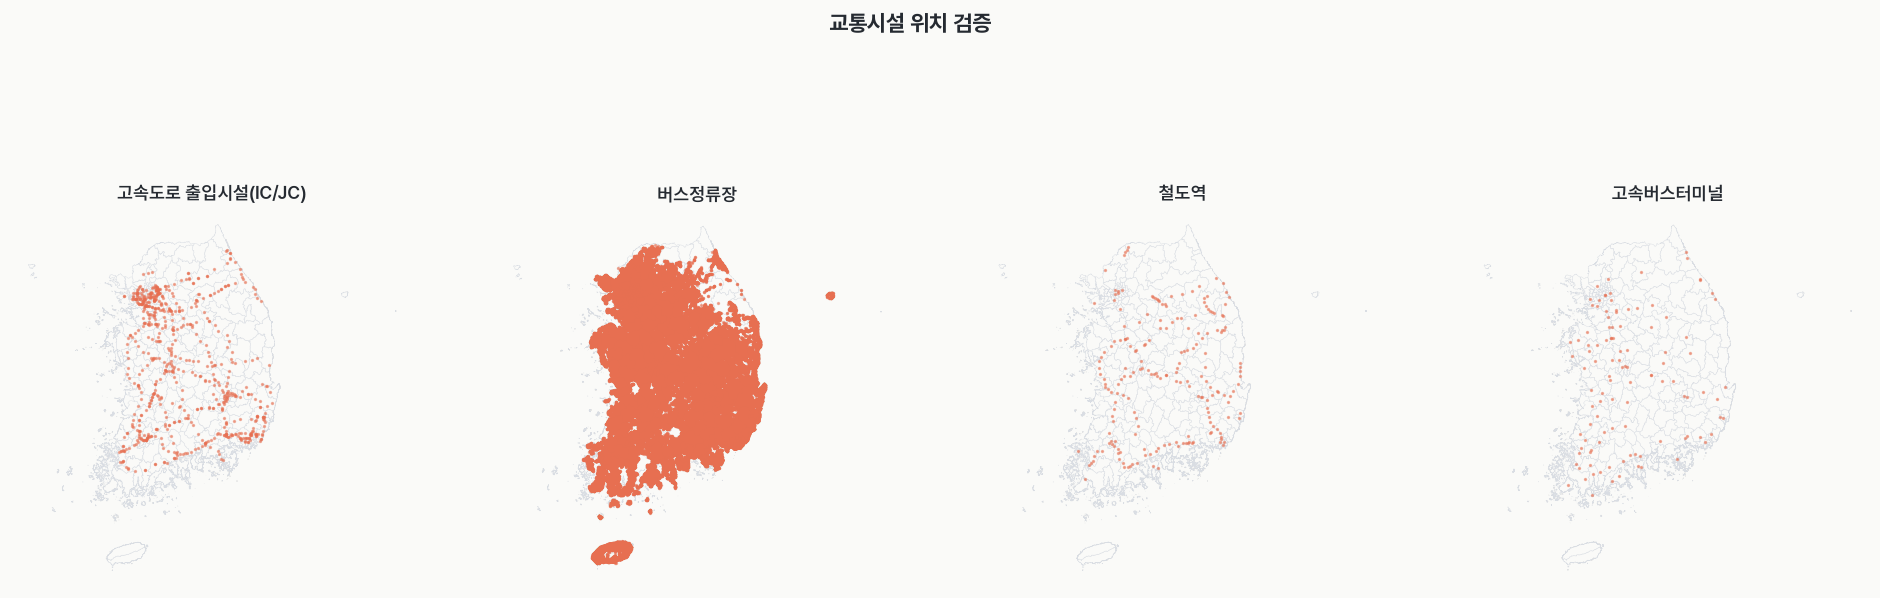

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(24, 8))
for ax, points_gdf, label in (
    (axes[0], road_entrance_gdf, "고속도로 출입시설(IC/JC)"),
    (axes[1], bus_stop_gdf.loc[bus_stop_gdf.geometry.notna()], "버스정류장"),
    (axes[2], rail_station_gdf, "철도역"),
    (axes[3], bus_terminal_gdf, "고속버스터미널"),
):
    city_gdf.plot(ax=ax, color=COLORS["background"], edgecolor=COLORS["grid"], linewidth=0.3)
    points_gdf.plot(ax=ax, markersize=2, color=COLORS["accent"], alpha=0.5)
    ax.set_axis_off()
    ax.set_title(label)
fig.suptitle("교통시설 위치 검증")
plt.show()
plt.close(fig)

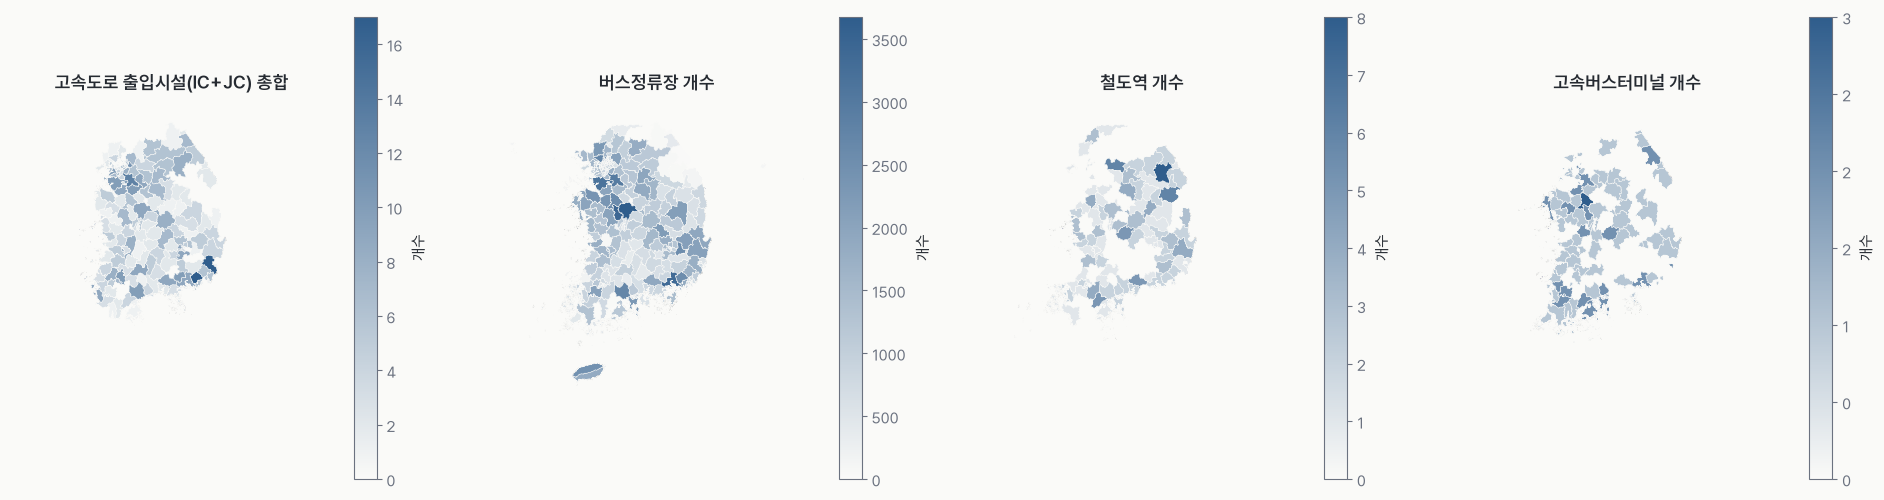

In [12]:
map_gdf = city_gdf.merge(wide_table, on=["시도명", "시군구명"], how="outer", indicator=True)
assert (map_gdf["_merge"] == "both").all(), "지도용 결합에 실패한 시군구가 있습니다."
map_gdf = map_gdf.drop(columns="_merge")

SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "seq_primary", [COLORS["background"], COLORS["primary"]]
)


def plot_choropleth(column: str, title: str, ax: plt.Axes) -> None:
    """시군구별 개수 단계구분도를 그린다.

    Args:
        column: 그릴 개수 열 이름.
        title: 지도 제목.
        ax: 그릴 대상 Axes.
    """
    map_gdf.plot(
        column=column,
        cmap=SEQUENTIAL_CMAP,
        vmin=0,
        linewidth=0.3,
        edgecolor=COLORS["background"],
        legend=True,
        legend_kwds={"shrink": 0.6, "format": "%.0f", "label": "개수"},
        ax=ax,
    )
    ax.set_axis_off()
    ax.set_title(title)


fig, axes = plt.subplots(1, 4, figsize=(24, 10))
plot_choropleth("고속도로출입시설수_총합", "고속도로 출입시설(IC+JC) 총합", axes[0])
plot_choropleth("버스정류장수", "버스정류장 개수", axes[1])
plot_choropleth("철도역수", "철도역 개수", axes[2])
plot_choropleth("고속버스터미널수", "고속버스터미널 개수", axes[3])
plt.show()
plt.close(fig)

## 11. 핵심 결과와 한계

- 국민여행조사 전용 지역코드 229개 시군구를 key로, 고속도로 출입시설
  유형(IC/JC)별 개수·총합, 버스정류장 개수, 철도역 개수, 고속버스
  터미널 개수를 결합해
  `outputs/260723_교통_시설_시군구_집계/tables/`에 저장했다.
- 버스정류장·철도역 CSV는 GeoDataFrame으로 변환해
  `data/preprocess/transportation/`에 geojson으로도 저장했다(원본
  CSV는 그대로 둠). 고속버스터미널은 원본이 이미 geojson이라 좌표계
  (EPSG:5179→4326)만 맞추고 별도 저장은 하지 않았다.
- 원자료 point 수와 시군구 집계 총합이 정확히 일치한다: 고속도로
  출입시설 689개(IC 535, JC 154), 철도역 202개, 고속버스터미널
  109개는 전량 결합됐고, 버스정류장은 227,065개 중 위치를 확인할 수
  없는 6개(결측 5, 위도=경도로 신뢰 불가 1)를 제외한 227,059개가
  결합됐다.
- 버스정류장 원자료의 위도·경도가 뒤바뀐 6개는 좌표를 맞바꿔
  복원했다. 네 원자료 모두 경계 인근에서 `within` 판정에 실패한
  point(다리 위 정류장, 좌표 반올림 등)는 `sjoin_nearest`로
  보정했으며 보정 거리는 모두 수 km 이내였다.
- 군위군은 이 노트북의 key 테이블에서만 대구광역시로 고쳤고 원본
  지역코드 CSV는 그대로 두었다. 인천 남구/미추홀구도 결합 시점에만
  지역코드가 쓰는 옛 이름으로 통일했다.
- 해당 교통시설이 없는 시군구는 0으로 채웠으며, 이는 실제 부재와
  원자료 누락을 구분하지 못한다는 한계가 있다.
- 버스정류장 개수는 노선·배차 간격을 반영하지 않는 정류장 지점
  수이며, 철도역·고속버스터미널 개수도 역·터미널의 규모나 운행
  편수를 반영하지 않는다.